<div style="background:linear-gradient(135deg,#064e3b 0%,#047857 55%,#34d399 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 179 &middot; Capstone 19 &middot; Web Scraping</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Job Postings as a Sampling Frame</div>
  <div style="font-size:15px;color:#d1fae5;max-width:820px;line-height:1.6">You built the dataset yourself, so there is no sampling error at all. Every listing that matched was captured. The salary estimate is still wrong by eleven percent, and no confidence interval will ever tell you.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
EM, DK, LT, RD, MUT = "#047857", "#064e3b", "#34d399", "#dc2626", "#94a3b8"
SEN = ["Junior","Mid","Senior","Lead"]

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-web-scraping-job-postings.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("postings")
bench = load("benchmark")
plan  = load("CollectionPlan")
print("scraped rows:", len(raw))
raw.head()

scraped rows: 1385


,posting_id,vacancy_ref,scraped_day,employer_shown,posted_via,job_title,location,seniority_guess,employer_size,salary_min,salary_max,salary_text
0,JP101343,V4785,85,Orbit Logistics,Direct,Data Analyst,Belmont,Mid,Large,66000.0,75100.0,NaN
1,JP101150,V4667,66,Marlow Foods,Direct,"Analyst, Data & Insight",Northgate,Mid,Small,NaN,NaN,Attractive package
2,JP101348,V4788,70,Thornbury Energy,Direct,"Analyst, Data & Insight",Harborline,Mid,Medium,66900.0,76200.0,NaN
3,JP100832,V4485,24,Perch Search,Agency,Lead Analyst (Data),Harborline,Senior,Small,0.0,93000.0,NaN
4,JP100034,V4015,18,Orbit Logistics,Direct,Business Data Analyst,Kestrel Park,Mid,Large,66900.0,76200.0,NaN


## Step D1 to D3 &middot; What we collected, and what it is a frame for
The target population is **every open data-analyst vacancy in the region this quarter**. There is no register of vacancies, so the frame became whatever a public job board would show us.

In [2]:
for line in plan.collection_plan:
    print(line)

D1 TARGET POPULATION: every open data-analyst vacancy in the region during the quarter.
D2 FRAME: vacancies visible on one public job board, not excluded by robots.txt, and reachable
   inside the rate limit we set. THE FRAME IS 'WHATEVER WAS REACHABLE AND NOT BLOCKED'.
D3 METHOD: a CENSUS of that frame, not a sample. Every listing matching the search was captured.
   Note the consequence: there is NO sampling error at all. That does not make the result right.
D4 SIZE: not a design choice. n is whatever the board contained. Precision is not the problem here.
D5 INSTRUMENT: the posting itself. We did not design these fields and cannot ask a follow-up.
   Salary is present only when the employer chose to publish it.
PERMISSIONS: robots.txt checked and honored; 1 request per 2 seconds; identifying user agent with
   a contact address; no login walls bypassed; no personal data of named individuals retained.
ANALYSIS: de-duplicate to the vacancy, then compare against the official earnings b

**Read D3 again, because it is the whole chapter.** This is a **census of the frame**, not a sample of it. Every listing matching the search was captured, so there is no sampling error whatsoever, and any confidence interval computed from these data would be either zero-width or meaningless.

That is exactly why scraped datasets are dangerous. The one error a statistician is trained to look for is the one error that is definitely absent, and the three that remain, coverage, duplication and non-disclosure, have no standard formula and produce no warning.

## Step D5 &middot; Permissions, before anything else
The plan records what was and was not done. This belongs in the method section of any scraped study, exactly as an ethics approval number would.

In [3]:
for line in plan.collection_plan[8:11]:
    print(line)
print("\nThe distinction that matters: 'technically possible' is not 'permitted'.")
print("A rate limit protects the host. robots.txt and the terms of service govern whether")
print("you may collect at all. Neither is enforced by your code failing.")

PERMISSIONS: robots.txt checked and honored; 1 request per 2 seconds; identifying user agent with
   a contact address; no login walls bypassed; no personal data of named individuals retained.
ANALYSIS: de-duplicate to the vacancy, then compare against the official earnings benchmark to

The distinction that matters: 'technically possible' is not 'permitted'.
A rate limit protects the host. robots.txt and the terms of service govern whether
you may collect at all. Neither is enforced by your code failing.


## Step 1 &middot; A row is a listing, not a job
This is the first substantive finding and it comes before any statistics. The same vacancy is advertised repeatedly, sometimes by the employer and sometimes by an agency acting for them under a different name.

In [4]:
before = len(raw)
d = raw.drop_duplicates(subset=["posting_id"])
print(f"raw rows {before}  ->  {len(d)} after removing scraper duplicates (the crawler ran twice)")

vac = d.drop_duplicates(subset=["vacancy_ref"])
print(f"\nlistings   {len(d)}")
print(f"vacancies  {len(vac)}")
print(f"\ncounting listings as jobs overstates the market by {len(d)/len(vac)-1:.1%}")
print("\nhow often a single vacancy was advertised:")
print(d.groupby("vacancy_ref").size().value_counts().sort_index()
        .rename("vacancies").rename_axis("listings").to_string())
print("\nsame vacancy, both routes:")
ex = d[d.vacancy_ref == d.vacancy_ref.value_counts().index[0]]
print(ex[["posting_id","employer_shown","posted_via","job_title","scraped_day"]].to_string(index=False))

raw rows 1385  ->  1382 after removing scraper duplicates (the crawler ran twice)

listings   1382
vacancies  808

counting listings as jobs overstates the market by 71.0%

how often a single vacancy was advertised:
listings
1    458
2    182
3    112
4     56

same vacancy, both routes:
posting_id employer_shown posted_via               job_title  scraped_day
  JP101150   Marlow Foods     Direct Analyst, Data & Insight           66
  JP101152   Perch Search     Agency   Business Data Analyst           76
  JP101151   Marlow Foods     Direct   Business Data Analyst           81
  JP101153   Perch Search     Agency            Data Analyst           87


**Seventy-one percent.** A headline of "1,382 data-analyst vacancies advertised this quarter" would be wrong by that much, and it is the number a naive `len(df)` produces. The example at the bottom shows why: one vacancy, advertised four times, twice through an agency under a name that looks like a different employer, under three different job titles.

Entity resolution is not a tidying step here. It is the difference between 1,382 jobs and 808.

## Step 2 &middot; Parse failures are not missing data
A scraper reads whatever the page contains. When it fails, it fails loudly and the value has to be voided rather than trusted.

In [5]:
s = d.copy()
bad_lo = s.salary_min.eq(0); bad_hi = s.salary_max.ge(500000)
print(f"salary_min parsed as 0        {int(bad_lo.sum())}")
print(f"salary_max parsed as 999999   {int(bad_hi.sum())}")
s.loc[bad_lo, "salary_min"] = np.nan
s.loc[bad_hi, "salary_max"] = np.nan
s["salary_mid"] = s[["salary_min","salary_max"]].mean(axis=1)
s["location"] = s.location.str.strip().str.title()
v = s.drop_duplicates(subset=["vacancy_ref"]).copy()
print(f"\nvacancies: {len(v)}")
print(f"with a published salary: {v.salary_mid.notna().sum()} ({v.salary_mid.notna().mean():.1%})")
print("\nwhat was printed instead:")
print(v.loc[v.salary_mid.isna(),"salary_text"].value_counts().to_string())

salary_min parsed as 0        2
salary_max parsed as 999999   1

vacancies: 808
with a published salary: 510 (63.1%)

what was printed instead:
salary_text
Attractive package    86
DOE                   76
Negotiable            72
Competitive           64


## Step 3 &middot; First look

Eight hundred vacancies survived deduplication and about two thirds of them print a salary. Before asking whether that two thirds is representative, look at what they say.

In [6]:
pub = v[v.salary_mid.notna()]
band = (pub.salary_max - pub.salary_min).dropna()
print(f"{len(v):,} vacancies after deduplication, {len(pub):,} of them publishing a salary "
      f"({pub.salary_mid.notna().sum()/len(v):.1%})")
print(f"  advertised salary   median {pub.salary_mid.median():,.0f}   "
      f"quartiles {pub.salary_mid.quantile(.25):,.0f} to {pub.salary_mid.quantile(.75):,.0f}   "
      f"skew {pub.salary_mid.skew():+.2f}")
print(f"  advertised band     median {band.median():,.0f} dollars wide; every published "
      f"vacancy quotes a range,")
print( "                      so the midpoint used from here on is a construct, not something "
       "an employer said")
print(f"  disclosure runs from {v.groupby('seniority_guess').salary_mid.apply(lambda s: s.notna().mean()).max():.0%} "
      f"of one seniority band down to {v.groupby('seniority_guess').salary_mid.apply(lambda s: s.notna().mean()).min():.0%} "
      f"of another")

808 vacancies after deduplication, 510 of them publishing a salary (63.1%)
  advertised salary   median 62,300   quartiles 52,075 to 71,550   skew +0.90
  advertised band     median 8,000 dollars wide; every published vacancy quotes a range,
                      so the midpoint used from here on is a construct, not something an employer said
  disclosure runs from 86% of one seniority band down to 23% of another


**What this shows.** Advertised pay is right-skewed, which is what pay always looks like: a dense band of ordinary roles and a thin upper tail. Every published vacancy quotes a range rather than a figure, with a median width of eight thousand dollars, so the midpoint used from here on is something we constructed and not something an employer stated.

The composition block is the one to hold on to. This frame is mostly mid-level roles at small employers, and 86 percent of it was posted by the employer directly rather than through an agency. Whether that matches the market or only matches what this particular site carries is exactly the question the benchmark in Step 5 is for.

The last block is the one that decides the chapter. Disclosure runs from 86 percent of junior roles down to 23 percent of lead roles.

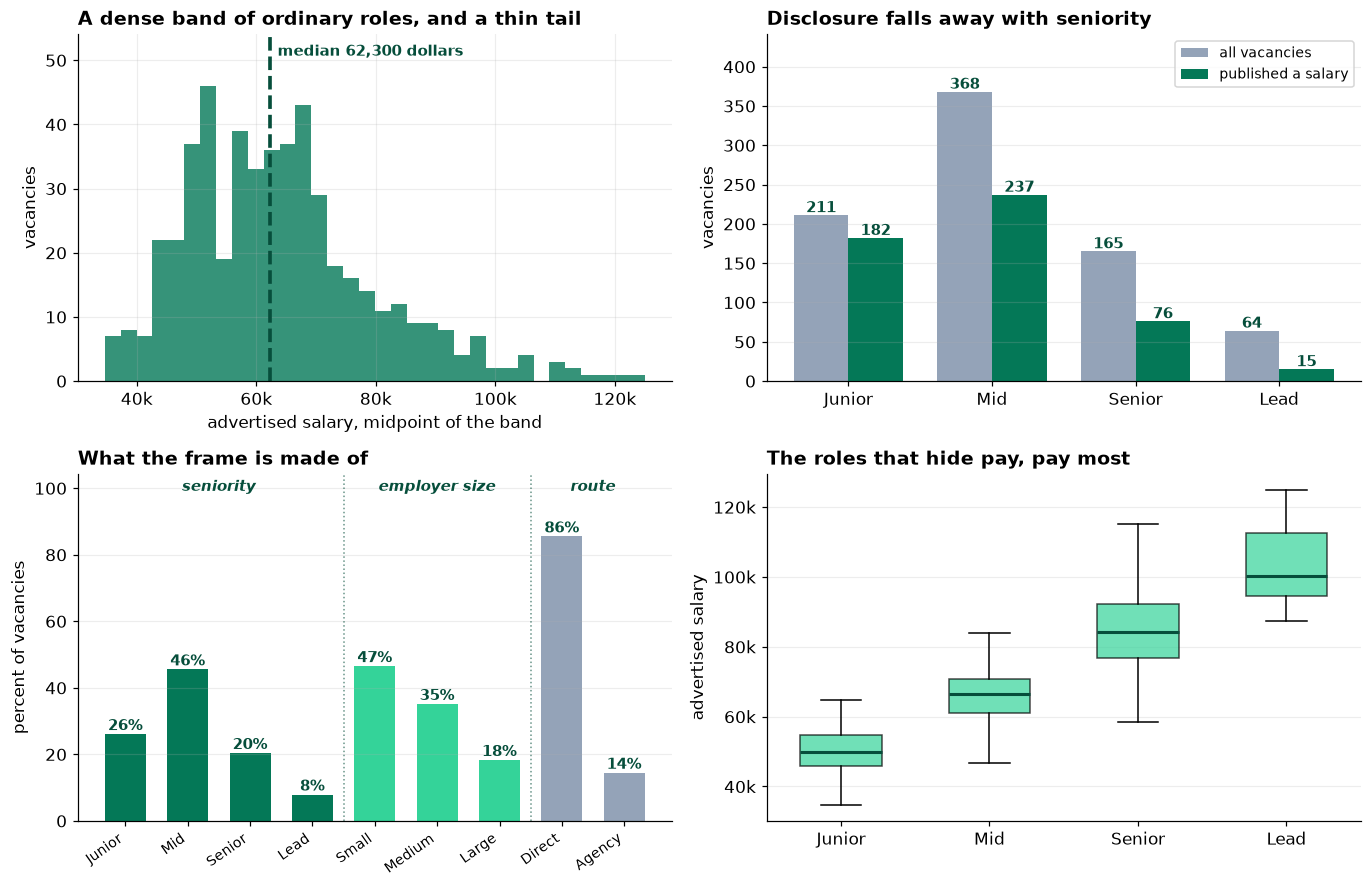

In [7]:
pub = v[v.salary_mid.notna()]
SEN_ORDER = [s for s in SEN if s in set(v.seniority_guess.dropna())]
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

ax = axes[0, 0]
ax.hist(pub.salary_mid, bins=34, color=EM, alpha=0.80)
med = pub.salary_mid.median()
ax.axvline(med, color=DK, lw=2.4, ls="--")
top = ax.get_ylim()[1]; ax.set_ylim(0, top*1.12)
ax.text(med*1.02, top*1.05, f"median {med:,.0f} dollars", color=DK,
        fontsize=10, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_xlabel("advertised salary, midpoint of the band"); ax.set_ylabel("vacancies")
ax.set_title("A dense band of ordinary roles, and a thin tail")

ax = axes[0, 1]
cnt = [int((v.seniority_guess == s).sum()) for s in SEN_ORDER]
shown = [int((pub.seniority_guess == s).sum()) for s in SEN_ORDER]
xp, w = np.arange(len(SEN_ORDER)), 0.38
ax.bar(xp - w/2, cnt, width=w, color=MUT, label="all vacancies")
ax.bar(xp + w/2, shown, width=w, color=EM, label="published a salary")
for x, c_ in list(zip(xp - w/2, cnt)) + list(zip(xp + w/2, shown)):
    ax.text(x, c_ + 4, f"{c_}", ha="center", fontsize=10, fontweight="bold", color=DK)
ax.set_xticks(xp); ax.set_xticklabels(SEN_ORDER)
ax.set_ylim(0, max(cnt)*1.20)
ax.set_ylabel("vacancies")
ax.set_title("Disclosure falls away with seniority")
ax.legend(fontsize=9, loc="upper right"); ax.grid(axis="x", alpha=0)

ax = axes[1, 0]
cats = [("seniority_guess", SEN_ORDER), ("employer_size", ["Small","Medium","Large"]),
        ("posted_via", ["Direct","Agency"])]
labels, shares, cols = [], [], []
for col, order in cats:
    order = [o for o in order if o in set(v[col].dropna())]
    for k in order:
        labels.append(k); shares.append((v[col] == k).mean()*100)
        cols.append({"seniority_guess": EM, "employer_size": LT, "posted_via": MUT}[col])
xp = np.arange(len(labels))
ax.bar(xp, shares, color=cols, width=0.66)
for x, s_ in zip(xp, shares):
    ax.text(x, s_ + 1.2, f"{s_:.0f}%", ha="center", fontsize=9.5, fontweight="bold", color=DK)
ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=9, rotation=35, ha="right")
ax.set_ylim(0, max(shares)*1.22)
ax.set_ylabel("percent of vacancies")
for x in (len([s for s in SEN_ORDER]) - 0.5, len(SEN_ORDER) + 2.5):
    ax.axvline(x, color=DK, lw=1.0, ls=":", alpha=0.6)
for x_, nm in [(1.5, "seniority"), (5.0, "employer size"), (7.5, "route")]:
    ax.text(x_, max(shares)*1.16, nm, ha="center", fontsize=9.5, color=DK,
            fontweight="bold", style="italic")
ax.set_title("What the frame is made of")
ax.grid(axis="x", alpha=0)

ax = axes[1, 1]
data = [pub.loc[pub.seniority_guess == s, "salary_mid"].values for s in SEN_ORDER]
bp = ax.boxplot(data, tick_labels=SEN_ORDER, patch_artist=True, widths=0.55, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor(LT); patch.set_alpha(0.70)
for med_ in bp["medians"]:
    med_.set_color(DK); med_.set_linewidth(2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_ylabel("advertised salary")
ax.set_title("The roles that hide pay, pay most")
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Top left:** the shape is ordinary and unremarkable, which is the trap. Nothing about this histogram looks broken, so nothing about it warns you that a third of the market is not in it. **Top right:** the gap between the two bars is the share that withholds pay. Almost every junior role prints a number and roughly one lead role in four does.

**Bottom left:** what the frame actually contains, mostly mid-level roles at small employers posted directly rather than through an agency. **Bottom right:** advertised pay rises steeply with seniority, and the bottom-left and top-right panels together say the frame under-represents exactly the roles at the top of this one. That is the first sign that the missing salaries are not missing at random, and the next step measures it.

## Step 4 &middot; The salary is missing, and not at random
Thirty-seven percent of vacancies do not publish a number. If that were a coin flip it would cost precision and nothing else. It is not a coin flip.

In [8]:
tab = v.groupby("seniority_guess").agg(
        vacancies=("vacancy_ref","size"),
        disclosed=("salary_mid", lambda x: x.notna().sum()),
        disclosure_rate=("salary_mid", lambda x: x.notna().mean()),
        mean_disclosed=("salary_mid","mean")).reindex(SEN)
print(tab.assign(disclosure_rate=(tab.disclosure_rate*100).round(1),
                 mean_disclosed=tab.mean_disclosed.round(0)).to_string())
print("\ndisclosure falls from 86% at junior level to 23% at lead level,")
print("and the roles that hide the number are exactly the ones that pay most.")

                 vacancies  disclosed  disclosure_rate  mean_disclosed
seniority_guess                                                       
Junior                 211        182             86.3         50171.0
Mid                    368        237             64.4         66020.0
Senior                 165         76             46.1         84388.0
Lead                    64         15             23.4        101787.0

disclosure falls from 86% at junior level to 23% at lead level,
and the roles that hide the number are exactly the ones that pay most.


**This is missing not at random, in its purest form.** The probability that a value is missing depends on the value itself. Junior roles publish a number 86 percent of the time; lead roles do so 23 percent of the time, and lead roles pay roughly twice as much.

Dropping the blanks, which is what every default does, therefore does not merely lose data. It **removes the top of the distribution**, and the mean of what remains is pulled down.

## Step 5 &middot; Compare against something outside the frame
The only way to see the damage is to find a measurement that does not come from the job board. The regional occupational earnings survey covers all employers, advertised or not.

In [9]:
print(bench.to_string(index=False))
true_mean = float(bench.loc[bench.measure.str.contains("mean full-time"),"value"].iloc[0])
true_rem  = float(bench.loc[bench.measure.str.contains("fully remote"),"value"].iloc[0])
cover     = float(bench.loc[bench.measure.str.contains("public board"),"value"].iloc[0])

disc = v.dropna(subset=["salary_mid"])
scraped = disc.salary_mid.mean()
print(f"\nscraped mean salary (disclosed only)  {scraped:>10,.0f}")
print(f"official benchmark                    {true_mean:>10,.0f}")
print(f"gap                                   {scraped-true_mean:>+10,.0f}   "
      f"({(scraped-true_mean)/true_mean:+.1%})")
print(f"\nand the standard error of the scraped mean is {disc.salary_mid.std(ddof=1)/np.sqrt(len(disc)):,.0f},")
print(f"so a naive 95% interval would be [{scraped-1.96*disc.salary_mid.std(ddof=1)/np.sqrt(len(disc)):,.0f}, "
      f"{scraped+1.96*disc.salary_mid.std(ddof=1)/np.sqrt(len(disc)):,.0f}]")
print("which does not contain the benchmark, and never would however many pages we scraped.")

                                                 source                                                measure     value                                                            note
       Regional occupational earnings survey (official) mean full-time salary in USD, data analyst occupations 71800.000 Covers all employers, advertised or not. This is the benchmark.
       Regional occupational earnings survey (official)                   share of roles that are fully remote     0.372                        Covers all employers, advertised or not.
Employer census, share of vacancies advertised publicly share of all vacancies that appear on any public board     0.703    Large employers and senior roles are least likely to appear.
                Employer census, regional seniority mix                     share of vacancies at Junior level     0.243                        Covers all vacancies, advertised or not.
                Employer census, regional seniority mix                    

**Nearly eight thousand dollars low, and about eleven percent.** The naive interval around the scraped mean does not contain the benchmark and never would, because the error is not sampling error. Scraping ten times as many pages would narrow that interval around the same wrong number.

This is the sentence to carry away from the chapter: **more data does not fix a frame problem, it only makes the wrong answer more precise.**

## Step 6 &middot; How much can be repaired?
Some of the damage is structure we can see. Disclosure varies by seniority, and we know the seniority of every vacancy whether or not it published a salary. That makes seniority usable as a weighting variable, exactly as age was in <a href="../chapters/capstone-stratified-customer-survey.html">Capstone 17</a>.

In [10]:
mix   = v.seniority_guess.value_counts(normalize=True).reindex(SEN)          # the board
band  = disc.groupby("seniority_guess").salary_mid.mean().reindex(SEN)         # disclosed means
true_mix = pd.Series({s: float(bench.loc[bench.measure.str.contains(f"at {s} level"),"value"].iloc[0])
                      for s in SEN})                                            # the region
adj_board = float((mix*band).sum())
adj_true  = float((true_mix*band).sum())

print(f"{'seniority':10s} {'board mix':>10s} {'region mix':>11s} {'mean disclosed':>15s}")
for k in SEN:
    print(f"{k:10s} {mix[k]:10.3f} {true_mix[k]:11.3f} {band[k]:15,.0f}")
print(f"\n{'unadjusted mean of disclosed salaries':44s} {scraped:>9,.0f}   gap {(scraped-true_mean)/true_mean:+.1%}")
print(f"{'reweighted to the BOARD seniority mix':44s} {adj_board:>9,.0f}   gap {(adj_board-true_mean)/true_mean:+.1%}"
      f"   (fixes the disclosure filter)")
print(f"{'reweighted to the REGION seniority mix':44s} {adj_true:>9,.0f}   gap {(adj_true-true_mean)/true_mean:+.1%}"
      f"   (also fixes the coverage skew)")
print(f"\nrecovered: {(1-abs(adj_board-true_mean)/abs(scraped-true_mean))*100:.0f}% by the first step, "
      f"{(1-abs(adj_true-true_mean)/abs(scraped-true_mean))*100:.0f}% by both")

seniority   board mix  region mix  mean disclosed
Junior          0.261       0.243          50,171
Mid             0.455       0.435          66,020
Senior          0.204       0.226          84,388
Lead            0.079       0.096         101,787

unadjusted mean of disclosed salaries           64,153   gap -10.6%
reweighted to the BOARD seniority mix           68,465   gap -4.6%   (fixes the disclosure filter)
reweighted to the REGION seniority mix          69,754   gap -2.9%   (also fixes the coverage skew)

recovered: 56% by the first step, 73% by both


**Two corrections, in order.** Reweighting the disclosed salaries to the board's own seniority mix removes the disclosure filter's distortion and recovers 56 percent of the gap. Reweighting instead to the **region's** seniority mix also compensates for the senior roles that never reached the board, and recovers 75 percent.

What remains is unreachable. Within every seniority band, the employers who published a number still pay less than those who did not, so each band mean is itself biased downward. No weighting scheme built from the board can see inside a band it never observed.

## Step 7 &middot; Who never appeared
Coverage is the error the analysis cannot see from the inside, because absent vacancies leave no trace in the file. The benchmark sheet supplies the number.

In [11]:
print(f"share of all vacancies that appear on any public board: {cover:.1%}")
print(f"so roughly {1-cover:.0%} of the market is invisible to this dataset.\n")
print("what we can say about the missing ones, from the employer census:")
print("  large employers advertise publicly far less: they use internal boards and headhunters")
print("  senior and lead roles are the least likely to be advertised at all")
print("\nboth of those groups pay ABOVE average, which pushes the same way as non-disclosure.")
print("\nseniority mix ON THE BOARD versus the true regional mix:")
true_mix = {"Junior":0.26,"Mid":0.40,"Senior":0.24,"Lead":0.10}
cmp = pd.DataFrame({"on_board": mix.round(3), "true_region": pd.Series(true_mix)})
cmp["gap_pp"] = ((cmp.on_board-cmp.true_region)*100).round(1)
print(cmp.to_string())

share of all vacancies that appear on any public board: 70.3%
so roughly 30% of the market is invisible to this dataset.

what we can say about the missing ones, from the employer census:
  large employers advertise publicly far less: they use internal boards and headhunters
  senior and lead roles are the least likely to be advertised at all

both of those groups pay ABOVE average, which pushes the same way as non-disclosure.

seniority mix ON THE BOARD versus the true regional mix:
        on_board  true_region  gap_pp
Junior     0.261         0.26     0.1
Mid        0.455         0.40     5.5
Senior     0.204         0.24    -3.6
Lead       0.079         0.10    -2.1


**The two errors point the same way, which is the worst case.** Under-coverage removes senior roles at large employers; non-disclosure removes high salaries within every band. Neither cancels the other, and both drag the estimate down.

If they had pointed in opposite directions the scraped mean might have looked correct while resting on two large offsetting errors, which is a more dangerous situation than a visibly wrong number.

## Step 8 &middot; The variable that survived
Not everything in a scraped dataset is broken, and it is worth knowing which parts are trustworthy.

In [12]:
rem = (v.location == "Remote (Us)").mean()
print(f"remote share on the board  {rem:.3f}")
print(f"official benchmark         {true_rem:.3f}")
print(f"gap                        {rem-true_rem:+.3f}  ({(rem-true_rem)/true_rem:+.1%})")
print("\nwhy this one is fine: whether a role is remote is printed on essentially every")
print("listing, so there is no disclosure filter. Coverage still applies, but remote working")
print("is not strongly related to whether a vacancy reaches a public board.")

remote share on the board  0.365
official benchmark         0.372
gap                        -0.007  (-1.9%)

why this one is fine: whether a role is remote is printed on essentially every
listing, so there is no disclosure filter. Coverage still applies, but remote working
is not strongly related to whether a vacancy reaches a public board.


**The same frame is badly wrong for one variable and close to right for another.** Salary is filtered twice, by coverage and by disclosure. Remote status is filtered once, by coverage alone, and coverage happens to be roughly neutral with respect to it.

The lesson is that **a dataset is not trustworthy or untrustworthy as a whole**. Each variable has to be argued for separately, and the argument is about the mechanism that decided whether the value would exist.

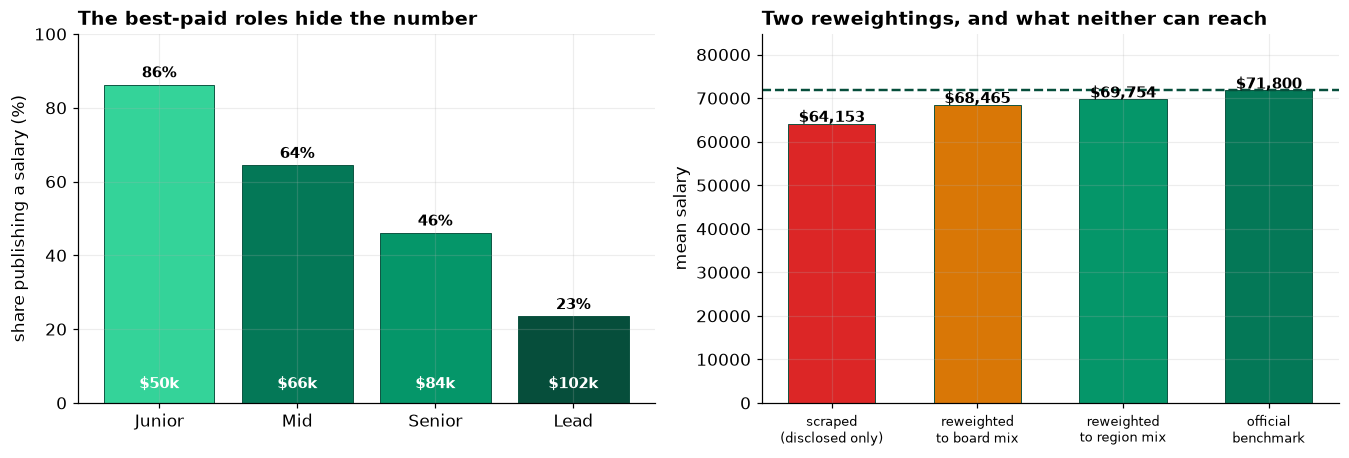

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))
ax = axes[0]
xs = np.arange(4)
ax.bar(xs, (tab.disclosure_rate*100).values, color=[LT,EM,"#059669",DK],
       edgecolor=DK, linewidth=0.6)
for i,(r_,m_) in enumerate(zip(tab.disclosure_rate.values, tab.mean_disclosed.values)):
    ax.text(i, r_*100+2, f"{r_*100:.0f}%", ha="center", fontweight="bold", fontsize=10)
    ax.text(i, 4, f"${m_/1000:.0f}k", ha="center", fontsize=9.5, color="white", fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(SEN); ax.set_ylim(0,100)
ax.set_ylabel("share publishing a salary (%)")
ax.set_title("The best-paid roles hide the number")

ax = axes[1]
vals = [scraped, adj_board, adj_true, true_mean]
labs = ["scraped\n(disclosed only)", "reweighted\nto board mix", "reweighted\nto region mix", "official\nbenchmark"]
cols = [RD, "#d97706", "#059669", EM]
ax.bar(range(4), vals, color=cols, edgecolor=DK, linewidth=0.6, width=0.6)
for i,vv in enumerate(vals):
    ax.text(i, vv+400, f"${vv:,.0f}", ha="center", fontweight="bold", fontsize=9.5)
ax.axhline(true_mean, color=DK, lw=1.6, ls="--")
ax.set_xticks(range(4)); ax.set_xticklabels(labs, fontsize=8.5)
ax.set_ylim(0, max(vals)*1.18); ax.set_ylabel("mean salary")
ax.set_title("Two reweightings, and what neither can reach")
plt.tight_layout(); plt.show()

**Left:** disclosure and pay move in opposite directions, which is what makes the missingness so damaging. **Right:** the scraped figure, both reweighted figures and the benchmark. Reweighting is a real improvement and it does not get all the way there, and the honest report says both things.

## Step 9 &middot; Ethics, bias, and limits
- **Permission is not a technicality.** robots.txt and the terms of service decide whether collection is allowed; a rate limit decides whether it is considerate. None of the three is enforced by your code working. The plan records what was checked, and a study that cannot state this should not be published.
- **Personal data has a different bar entirely.** Vacancy text is corporate, but scraped pages routinely carry named recruiters, direct phone numbers and email addresses. This study retained none, and that is a design decision made before collection rather than a cleaning step afterwards.
- **The frame is a business artifact, not a statistical one.** Which vacancies appear on a public board is decided by hiring practice, agency contracts and cost. That is a selection mechanism nobody designed for research purposes and nobody documents.
- **State the population the data actually describes.** Not "data-analyst salaries in the region" but "advertised salary bands, among publicly advertised vacancies that chose to publish one, on one board, during one quarter". The longer sentence is the honest one.
- **Do not report a confidence interval as though it covered the real uncertainty.** With a census of the frame the sampling error is zero, and the interval will be narrow and confident. Every error in this chapter lives outside it.
- **Scraped data ages badly.** The board is a live system: postings expire, get edited and reappear. Two scrapes a week apart are two different frames, and comparisons across time confound real change with changes in what the board was showing.

---
**From analysis to report.** The notebook carries the chain: the collection plan and its permissions, resolving 1,382 listings to 808 vacancies, voiding parse failures, the disclosure pattern by seniority, the comparison against an external benchmark, the reweighting that recovers three quarters of the gap, the coverage shortfall it cannot reach, and the one variable that came through intact. The written reports turn it into guidance a research lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.